<h1> Multiple curves in a single diagram </h1>

In [140]:
## Uncomment and run once

# import Pkg; 
# Pkg.add("GR")
# Pkg.add("StaticArrays")
# Pkg.add("OffsetArrays")
# Pkg.add("FileIO")
# Pkg.add("GeometryBasics")
# Pkg.add("UnicodePlots")

# TOC

- [Scatter](#Scatter)

[Back to the top](#TOC)

<hr/>

<h2>Outcome</h2>

After this lecture, you will be able to
- Use "if" to check for and remove non-numerical values in the data
- Plot several data series simultaneously
- Provide different markers and colours for the several data series
- Provide names to use in a legend for the plot

[Back to the top](#In-this-lecture)

<h2>"if" statements</h2>

The "if" statement, and variations thereof, are one of the most fundamental structures in  any programming language.

Basically, from time to time, a program needs to choose between a path on which to proceed.

The simplest choice is between doing something and doing nothing, which applies to a few of  the data in our West African EVD data set. Let's load it now to illustrate; we slice to show only the last 10 lines, which is where the missing data are. 

[Back to the top](#In-this-lecture)

In [141]:
using DelimitedFiles
EVDdata = readdlm("wikipediaEVDdatesconverted.csv", ',') # comma delimeted

54×9 Array{Any,2}:
 613  28637  11314  3804  2536  10675     4808     14122     3955
 606  28634  11314  3804  2536  10672     4808     14122     3955
 599  28635  11314  3805  2536  10672     4808     14122     3955
 592  28607  11314  3810  2536  10672     4808     14089     3955
 582  28539  11298  3806  2535  10672     4808     14061     3955
 575  28476  11298  3803  2535  10672     4808     14001     3955
 568  28454  11297  3800  2534  10672     4808     13982     3955
 554  28388  11296  3805  2533  10672     4808     13911     3955
 547  28295  11295  3800  2532  10672     4808     13823     3955
 540  28220  11291  3792  2530  10672     4808     13756     3953
 533  28147  11291  3792  2530  10672     4808     13683     3953
 526  28073  11290  3792  2529  10672     4808     13609     3953
 512  27952  11284  3786  2524  10672     4808     13494     3952
   ⋮                                ⋮                        
 140   1835   1011   506   373    599      323       730     

In [142]:
EVDdata[end-9:end, :] # get only last 10 elements

10×9 Array{Any,2}:
 123  1201  672  427  319  249     129     525     224
 114   982  613  411  310  174     106     397     197
 102   779  481  412  305  115      75     252     101
  87   528  337  398  264   33      24      97      49
  66   309  202  281  186   12      11      16       5
  51   260  182  248  171   12      11        "–"     "–"
  40   239  160  226  149   13      11        "-"     "-"
  23   176  110  168  108    8       2        "–"     "–"
   9   130   82  122   80    8       2        "–"     "–"
   0    49   29   49   29     "–"     "–"     "–"     "–"

We see that some of  them are not numbers. The last four columns (check the Wikipedia page again to confirm) are for Liberia and Sierra Leone. The absent data are because the first cases in those countries were reported after 22 March 2014.

We would like to change them. First let's look at "if" statements, via some examples

In [143]:
a = rand()
println("a now has the value $a")
if a > 0.5
    println("this is quite a large value")
end

a now has the value 0.8547583926886231
this is quite a large value


In [144]:
# let's run this through a for loop to see it many times
# NB! Note the  use of indentation to mark the start and end of the for and if structures
for k = 1:8
   a = rand()
   println("a now has the value $a")
   if a > 0.5
      println("this is quite a large value")
   end 
end

a now has the value 0.5777434590652539
this is quite a large value
a now has the value 0.849362775446802
this is quite a large value
a now has the value 0.16324076320936665
a now has the value 0.6187694029028168
this is quite a large value
a now has the value 0.08225968525014049
a now has the value 0.5760500197418752
this is quite a large value
a now has the value 0.23879864146191365
a now has the value 0.521597801977228
this is quite a large value


<h2>Using "for" and "if" to fill in missing data</h2>

Now we loop over *all* the data values. We use the function isnumber() to test whether the data value can be read as a number. This function returns either "true" or "false", so it is perfect for an "if" test.

And of course, whenever "isnumber(element)" evaluates to "false", we must replace the element with a number. I choose 0 as the replacement, but other choices also work (notably "NaN"). Note also that isnumber() as a test only works if the argument is a string. Since any string converts to a string, we can safely use the function string() to convert the numbers to strings before we test with isnumber.

In [145]:
function isNumeric(value)
    try
        parse(Float64, value)
        true
    catch
        false
    end
end

isNumeric (generic function with 1 method)

In [146]:
rows, cols = size(EVDdata)  # size() is a very useful function ... look it up with "? size"
for j = 1:cols
    for i = 1:rows  # this order goes does one column at a time
       if !isNumeric(string(EVDdata[i,j]))  # remember that "!" is the NOT operator (week 1, lecture 5)
         EVDdata[i,j] = 0
       end
   end
end

Let's check those last few rows to see how  it worked:

In [147]:
EVDdata[end-9:end, :]

10×9 Array{Any,2}:
 123  1201  672  427  319  249  129  525  224
 114   982  613  411  310  174  106  397  197
 102   779  481  412  305  115   75  252  101
  87   528  337  398  264   33   24   97   49
  66   309  202  281  186   12   11   16    5
  51   260  182  248  171   12   11    0    0
  40   239  160  226  149   13   11    0    0
  23   176  110  168  108    8    2    0    0
   9   130   82  122   80    8    2    0    0
   0    49   29   49   29    0    0    0    0

[Back to the top](#In-this-lecture)

<h2>Plotting the different countries' data simultaneously</h2>

This is rather easy. We provide a first series for the x-values (namely the  series epidays) and then we extract as an array the three columns with the individual countries. The plot is then a really simple function statement---that's the beauty of Plots.

In [148]:
# extract the data
epidays = EVDdata[:,1]

54-element Array{Any,1}:
 613
 606
 599
 592
 582
 575
 568
 554
 547
 540
 533
 526
 512
   ⋮
 140
 130
 123
 114
 102
  87
  66
  51
  40
  23
   9
   0

In [149]:
EVDcasesbycountry = EVDdata[:, [4,8] ] # = EVDdata[:, [4, 6, 8]]

54×2 Array{Any,2}:
 3804  14122
 3804  14122
 3805  14122
 3810  14089
 3806  14061
 3803  14001
 3800  13982
 3805  13911
 3800  13823
 3792  13756
 3792  13683
 3792  13609
 3786  13494
    ⋮  
  506    730
  472    574
  427    525
  411    397
  412    252
  398     97
  281     16
  248      0
  226      0
  168      0
  122      0
   49      0

[Back to the top](#In-this-lecture)

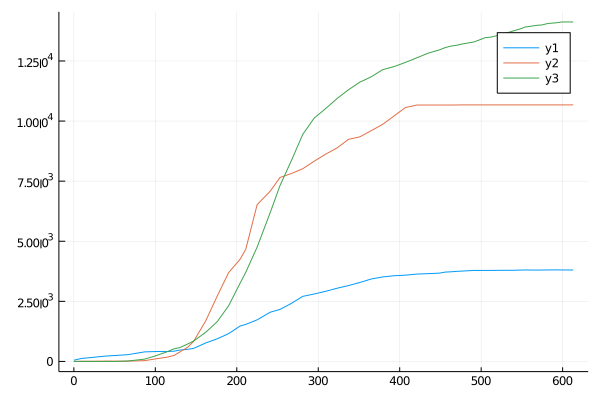

GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to un

In [150]:
using Plots
gr() # Activate the GR backend for use with Plots https://github.com/jheinen/GR.jl
plot(epidays, [EVDdata[:,4], EVDdata[:,6],  EVDdata[:,8]])

(-5, 36)
(-4, 15)
(-3, 0)
(-2, -9)
(-1, -12)
(0, -9)
(1, 0)
(2, 15)
(3, 36)
(4, 63)
(5, 96)


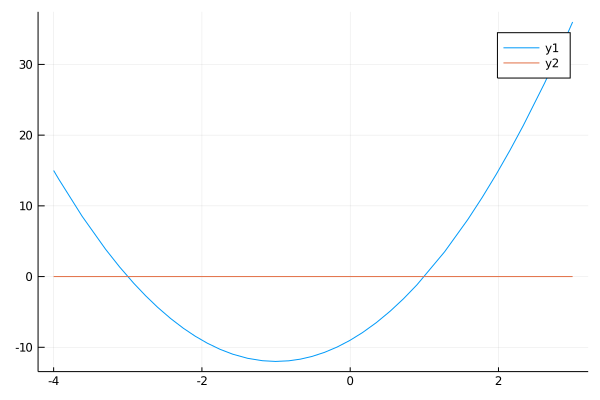

In [151]:
f(x) = 3 * x^2 + 6 * x - 9
for x = -5:5    
  println("(",x, ", ", f(x), ")")
end
using Plots
gr() # Activate the GR backend for use with Plots
plot(f, -4, 3) # plot f over [-4,4]
plot!(zero, -4, 3)

In [152]:
f(1)

0

<h2>Customising the simultanenous plot</h2>

The plot above is already fairly useful, but a better legend would help, and again I would prefer to be reminded that the data is only for every week or so, sometimes even less often. Title and axis labels are needed also. In this case perhaps the grid lines will also help to read the plot.

In [153]:
data = [1.6800483  -1.641695388; 
        0.501309281 -0.977697538; 
        1.528012113 0.52771122;
        1.70012253 1.711524991; 
        1.992493625 1.891000015;
        2.706075824 -0.463427794;
        2.994931927 -0.443566619;
        3.491852811 -1.275179133;
        3.501191722 -0.690499597;
        4.459924502 -5.516130799;
        4.936965851 -6.001703074;
        5.023289852 -8.36416901;
        5.04233698 -7.924477517;
        5.50739285 -10.77482371;
        5.568665171 -10.9171878]

15×2 Array{Float64,2}:
 1.68005    -1.6417
 0.501309   -0.977698
 1.52801     0.527711
 1.70012     1.71152
 1.99249     1.891
 2.70608    -0.463428
 2.99493    -0.443567
 3.49185    -1.27518
 3.50119    -0.6905
 4.45992    -5.51613
 4.93697    -6.0017
 5.02329    -8.36417
 5.04234    -7.92448
 5.50739   -10.7748
 5.56867   -10.9172

[Back to the top](#TOC)
<hr/>


# Scatter

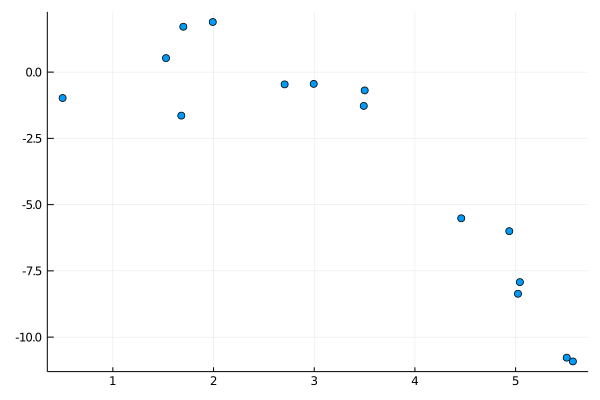

In [154]:
plot(data[:,1], data[:,2], linetype = :scatter, leg = false)

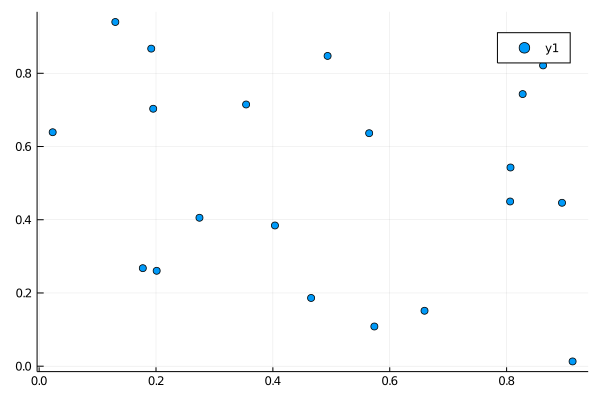

In [155]:
using Plots
gr()
n = 20
x = sort(rand(20)); y = rand(20)
Plots.scatter(x, y)

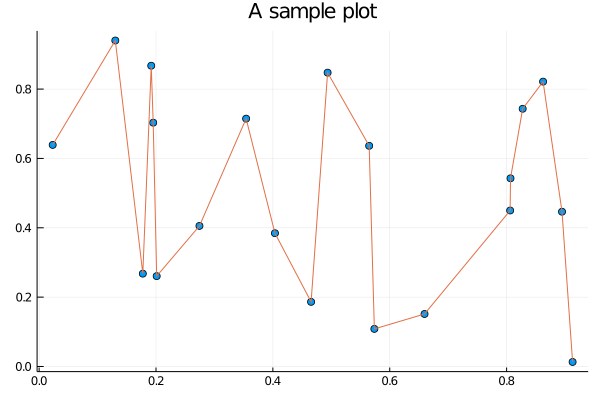

In [156]:
plot!(x, y, # ! means display on top of the previous plot
    leg=false, # legend
    title="A sample plot"
)

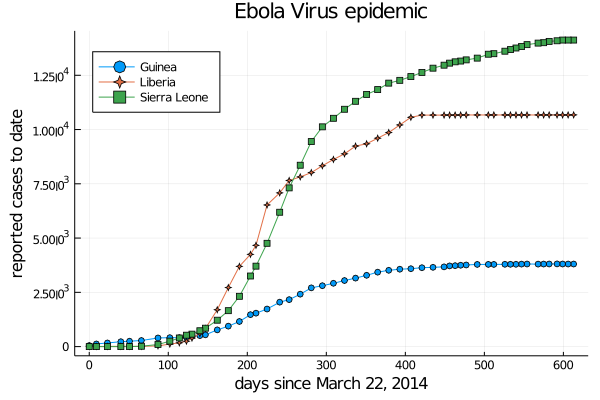

GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to un

In [157]:
plot(epidays, 
    [EVDdata[:,4], EVDdata[:,6],  EVDdata[:,8]],
    title     = "Ebola Virus epidemic",
    xlabel    = "days since March 22, 2014",
    ylabel    = "reported cases to date",
    marker    = ([ :octagon :star4 :square], 3),
    #line     = [(:path, :dot, :gray)], # = (:scatter)
    label     = ["Guinea" "Liberia" "Sierra Leone"],
    #legend   = true,
    legend    =:topleft, # :right, :left, :top, :bottom, :inside, :best, :legend, :topright, :topleft, :bottomleft, :bottomright
    grid      = true
    )


Ooops! The legend covers up part of the plot.

It can be tricky to place legends. Sometime, as here, one can specify a different position inside to plot area. Alternatively, a slightly transparent legend will show that the plot continues as expected below it (this is done by specifying an alpha level smaller than 1; look at the Plots website for details). Legends outside the plot area are also used.

The option "topleft" (again, note the use of ":" to show it is a value of an attribute) will do nicely, we have to pass it to the keyword "legend", see below:

In [158]:
plot(epidays, EVDcasesbycountry,
legend = :topleft,
marker = ([:octagon :star7 :square], 9),
label     = ["Guinea" "Liberia" "Sierra Leone"],
title      = "EVD in West Africa, epidemic segregated by country",
xlabel   = "Days since 22 March 2014",
ylabel   = "Number of cases to date",
line = (:scatter)
)


ErrorException: Cannot convert Array{Any,2} to series data for plotting

And why not save the plot?

In [159]:
savefig("L5testfig.pdf")

GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to unicode error
GKS: character ignored due to un

[Back to the top](#In-this-lecture)

In [160]:
import Pkg; Pkg.add("jupyter_core")
import jupyter_core
jupyter_core.paths.jupyter_config_dir()

Pkg.Types.PkgError: The following package names could not be resolved:
 * jupyter_core (not found in project, manifest or registry)


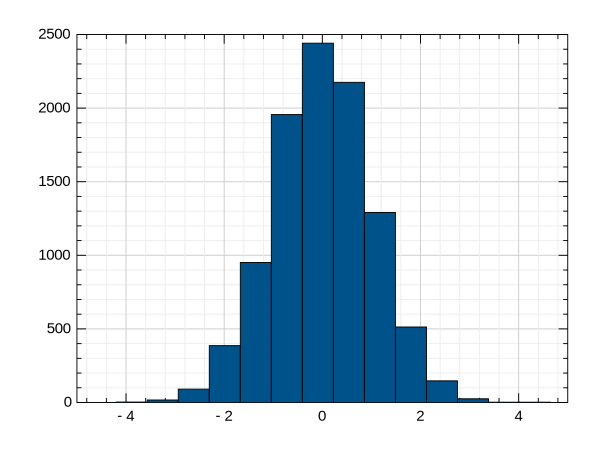

In [161]:

using GR
GR.histogram(randn(10000))

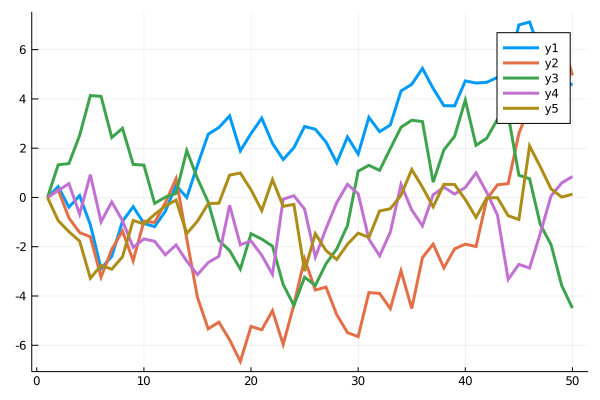

In [162]:
plot(Plots.fakedata(50, 5), w = 3)


In [163]:
p = plot([sin, cos], zeros(0), leg = false)
anim = Animation()
for x = range(0, stop = 10π, length = 100)
    push!(p, x, Float64[sin(x), cos(x)])
    frame(anim)
end

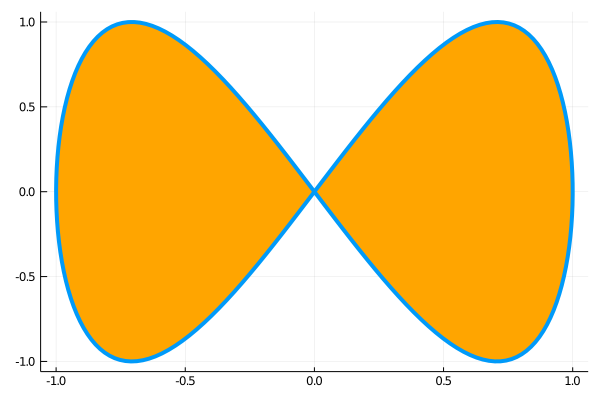

In [164]:
plot(sin, (x->begin
            sin(2x)
        end), 0, 2π, line = 4, leg = false, fill = (0, :orange))

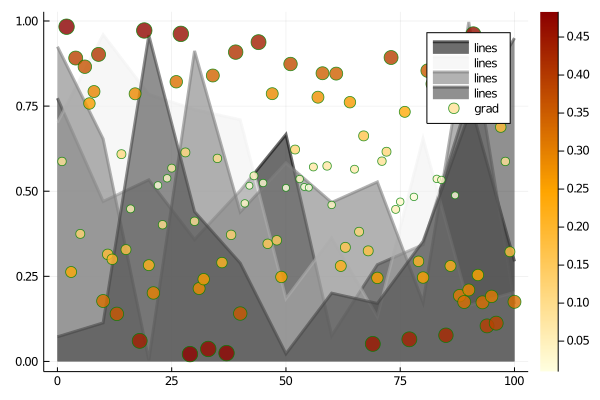

In [165]:
y = rand(100)
plot(0:10:100, rand(11, 4), lab = "lines", w = 3, palette = cgrad(:grays), fill = 0, α = 0.6)
scatter!(y, zcolor = abs.(y .- 0.5), m = (:heat, 0.8, Plots.stroke(1, :green)), ms = 10 * abs.(y .- 0.5) .+ 4, lab = "grad")


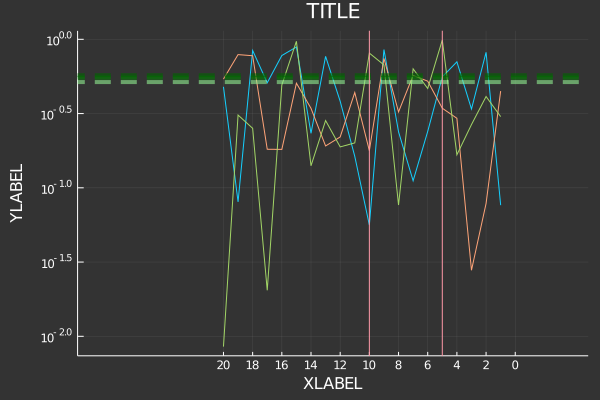

In [166]:
using Statistics
y = rand(20, 3)
plot(y, xaxis = ("XLABEL", (-5, 30), 0:2:20, :flip), background_color = RGB(0.2, 0.2, 0.2), leg = false)
hline!(mean(y, dims = 1) + rand(1, 3), line = (4, :dash, 0.6, [:lightgreen :green :darkgreen]))
vline!([5, 10])
title!("TITLE")
yaxis!("YLABEL", :log10)

┌ Info: Precompiling QuartzImageIO [dca85d43-d64c-5e67-8c65-017450d5d020]
└ @ Base loading.jl:1260


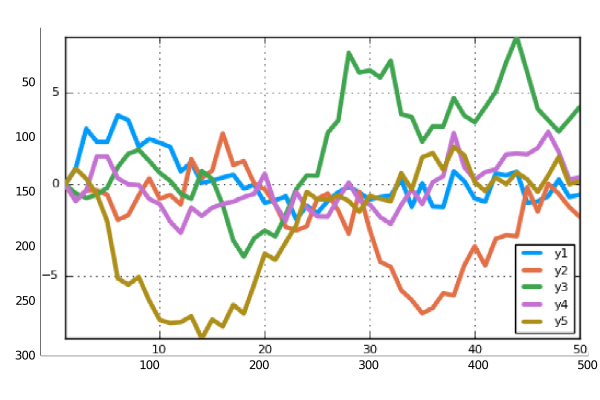

In [167]:

import FileIO
path = download("http://juliaplots.org/PlotReferenceImages.jl/Plots/pyplot/0.7.0/ref1.png")
img = FileIO.load(path)
plot(img)

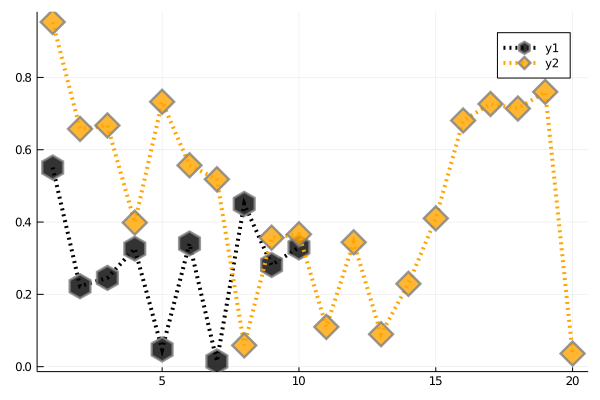

In [168]:
ys = Vector[rand(10), rand(20)]
plot(ys, color = [:black :orange], line = (:dot, 4), marker = ([:hex :d], 12, 0.8, Plots.stroke(3, :gray)))

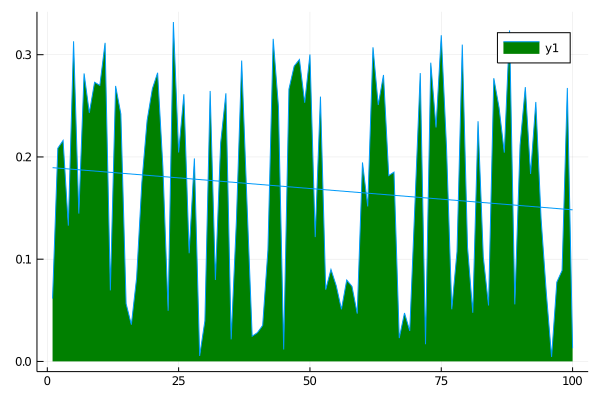

In [169]:
plot(rand(100) / 3, reg = true, fill = (0, :green))

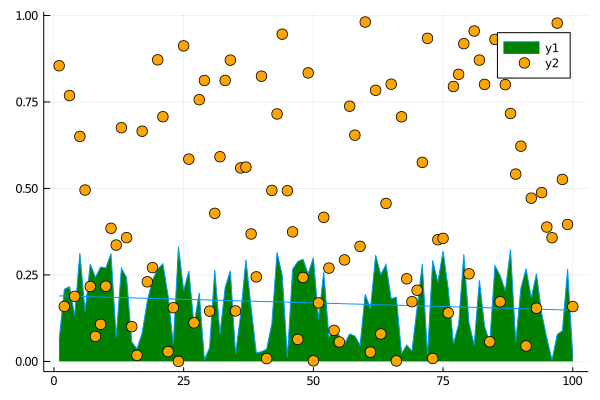

In [170]:
scatter!(rand(100), markersize = 6, c = :orange)

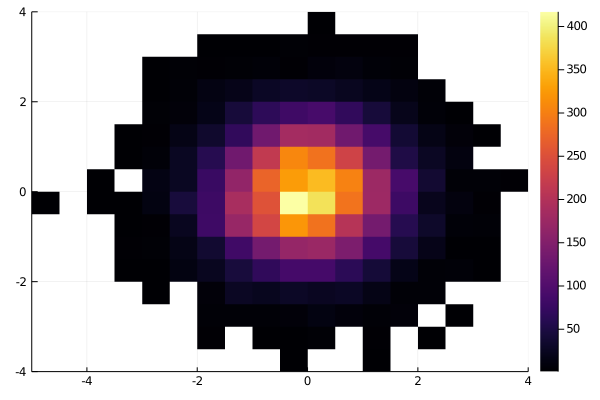

In [171]:
histogram2d(randn(10000), randn(10000), nbins = 20)


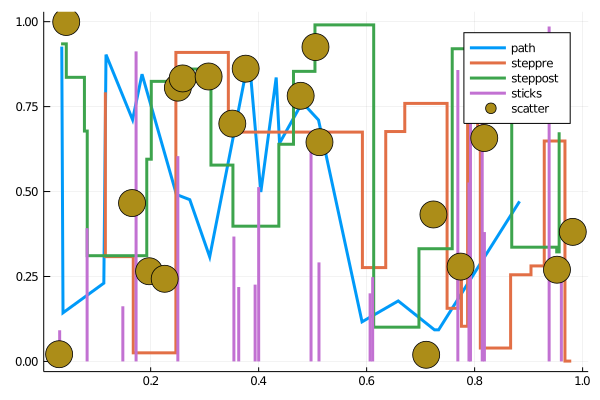

In [172]:
linetypes = [:path :steppre :steppost :sticks :scatter]
n = length(linetypes)
x = Vector[sort(rand(20)) for i = 1:n]
y = rand(20, n)
plot(x, y, line = (linetypes, 3), lab = map(string, linetypes), ms = 15)

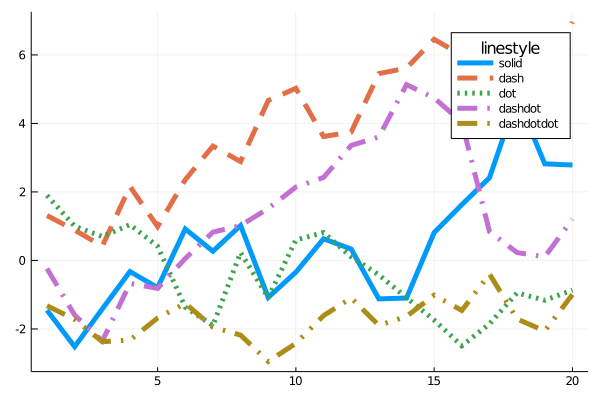

In [173]:
styles = filter((s->begin
                s in Plots.supported_styles()
            end), [:solid, :dash, :dot, :dashdot, :dashdotdot])
styles = reshape(styles, 1, length(styles))
n = length(styles)
y = cumsum(randn(20, n), dims = 1)
plot(y, line = (5, styles), label = map(string, styles), legendtitle = "linestyle")

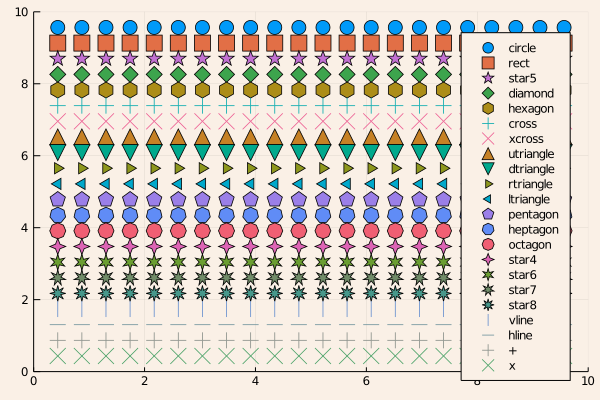

In [174]:
markers = filter((m->begin
                m in Plots.supported_markers()
            end), Plots._shape_keys)
markers = reshape(markers, 1, length(markers))
n = length(markers)
x = (range(0, stop = 10, length = n + 2))[2:end - 1]
y = repeat(reshape(reverse(x), 1, :), n, 1)
Plots.scatter(x, y, m = (8, :auto), lab = map(string, markers), bg = :linen, xlim = (0, 10), ylim = (0, 10))

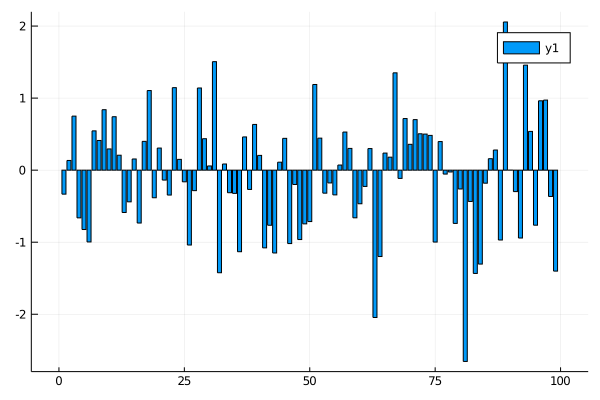

In [175]:
bar(randn(99))

In [176]:
histogram(randn(1000), bins = :scott, weights = repeat(1:5, outer = 200))

UndefVarError: UndefVarError: histogram not defined

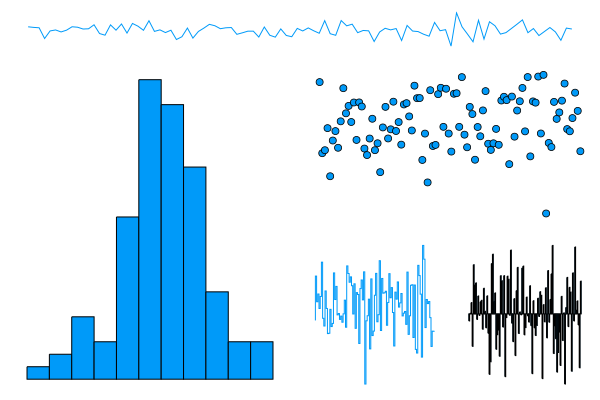

In [177]:
l = @layout([a{0.1h}; b [c; d e]])
plot(randn(100, 5), layout = l, t = [:line :histogram :scatter :steppre :bar], leg = false, ticks = nothing, border = :none)


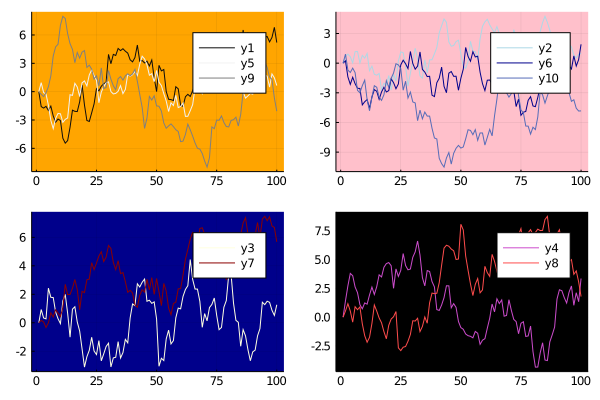

In [178]:
plot(Plots.fakedata(100, 10), layout = 4, palette = cgrad.([:grays :blues :heat :lightrainbow]), bg_inside = [:orange :pink :darkblue :black])



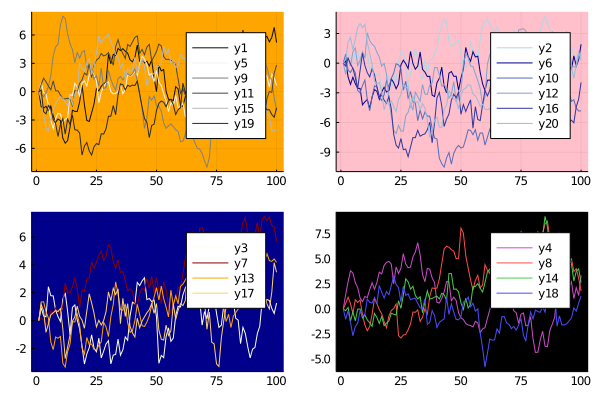

In [179]:
using Random
Random.seed!(111)
plot!(Plots.fakedata(100, 10))


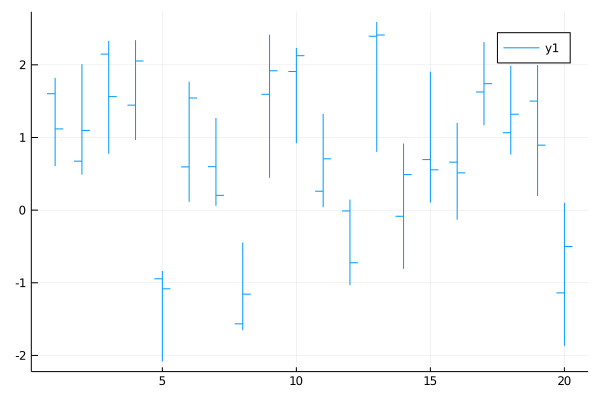

In [180]:
n = 20
hgt = rand(n) .+ 1
bot = randn(n)
openpct = rand(n)
closepct = rand(n)
y = OHLC[(openpct[i] * hgt[i] + bot[i], bot[i] + hgt[i], bot[i], closepct[i] * hgt[i] + bot[i]) for i = 1:n]
ohlc(y)

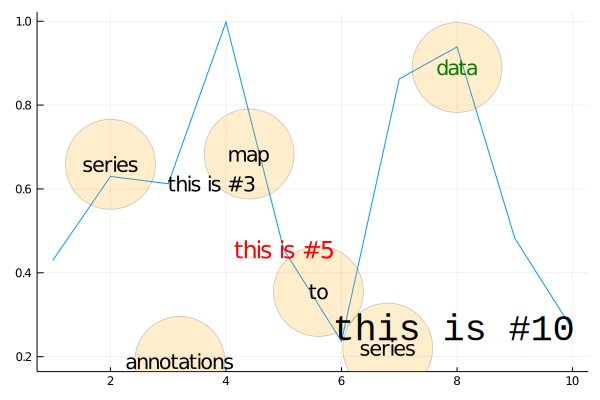

In [181]:
y = rand(10)
plot(y, annotations = (3, y[3], Plots.text("this is #3", :left)), leg = false)
annotate!([(5, y[5], Plots.text("this is #5", 16, :red, :center)), (10, y[10], Plots.text("this is #10", :right, 20, "courier"))])
scatter!(range(2, stop = 8, length = 6), rand(6), marker = (50, 0.2, :orange), series_annotations = ["series", "annotations", "map", "to", "series", Plots.text("data", :green)])

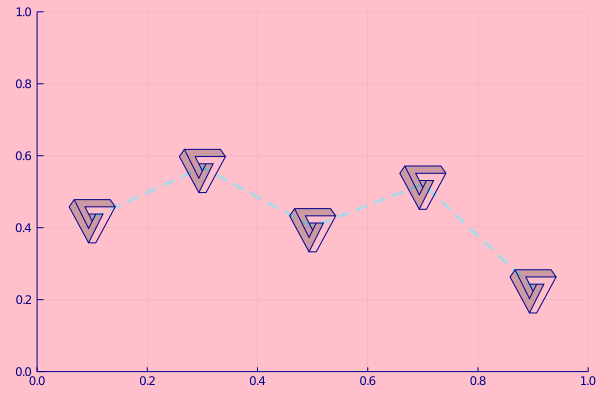

In [182]:
verts = [(-1.0, 1.0), (-1.28, 0.6), (-0.2, -1.4), (0.2, -1.4), (1.28, 0.6), (1.0, 1.0), (-1.0, 1.0), (-0.2, -0.6), (0.0, -0.2), (-0.4, 0.6), (1.28, 0.6), (0.2, -1.4), (-0.2, -1.4), (0.6, 0.2), (-0.2, 0.2), (0.0, -0.2), (0.2, 0.2), (-0.2, -0.6)]
x = 0.1:0.2:0.9
y = 0.7 * rand(5) .+ 0.15
plot(x, y, line = (3, :dash, :lightblue), marker = (Shape(verts), 30, RGBA(0, 0, 0, 0.2)), bg = :pink, fg = :darkblue, xlim = (0, 1), ylim = (0, 1), leg = false)

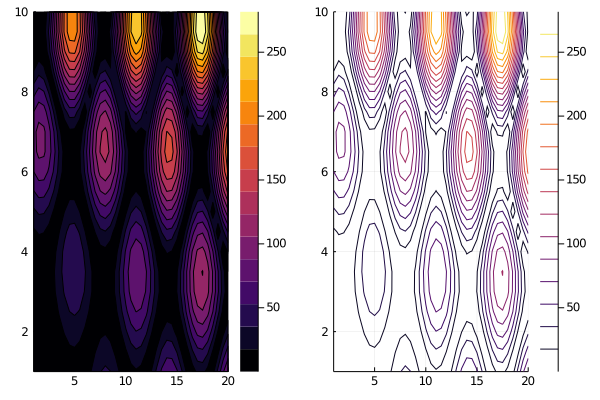

In [183]:
x = 1:0.5:20
y = 1:0.5:10
f(x, y) = begin
        (3x + y ^ 2) * abs(sin(x) + cos(y))
    end
X = repeat(reshape(x, 1, :), length(y), 1)
Y = repeat(y, 1, length(x))
Z = map(f, X, Y)
p1 = Plots.contour(x, y, f, fill = true)
p2 = Plots.contour(x, y, Z)
plot(p1, p2)

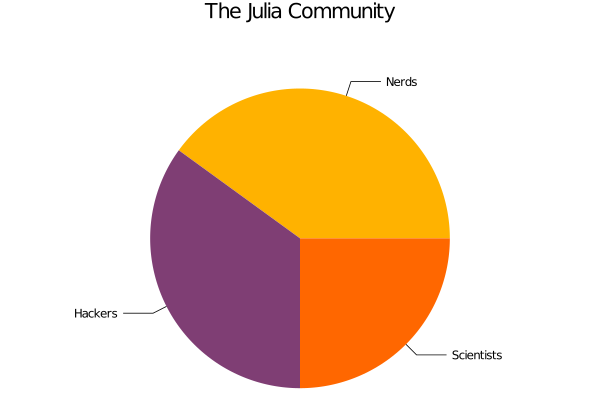

In [184]:
x = ["Nerds", "Hackers", "Scientists"]
y = [0.4, 0.35, 0.25]
pie(x, y, title = "The Julia Community", l = 0.5)

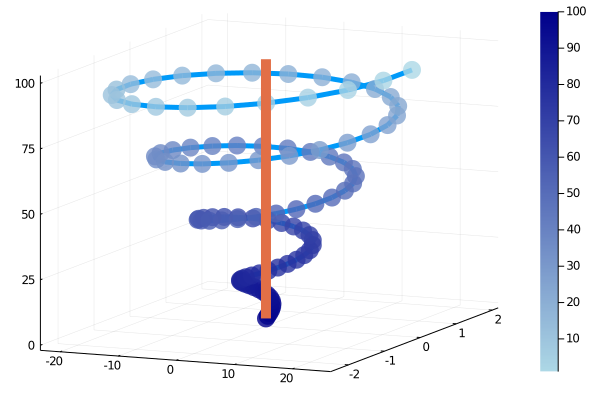

In [185]:
n = 100
ts = range(0, stop = 8π, length = n)
x = ts .* map(cos, ts)
y = (0.1ts) .* map(sin, ts)
z = 1:n
plot(x, y, z, zcolor = reverse(z), m = (10, 0.8, :blues, Plots.stroke(0)), leg = false, cbar = true, w = 5)
plot!(zeros(n), zeros(n), 1:n, w = 10)

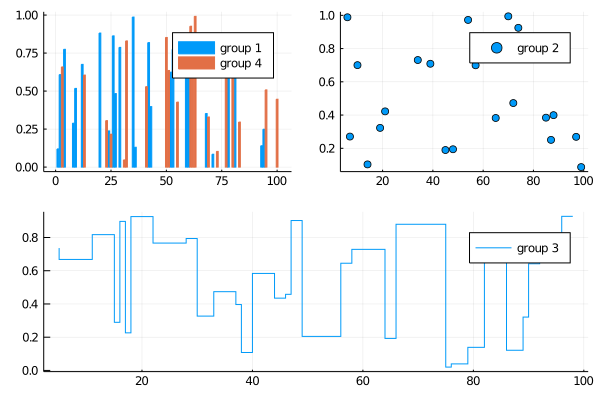

In [186]:
group = rand(map((i->begin
                    "group $(i)"
                end), 1:4), 100)
plot(rand(100), layout = @layout([a b; c]), group = group, linetype = [:bar :scatter :steppre], linecolor = :match)

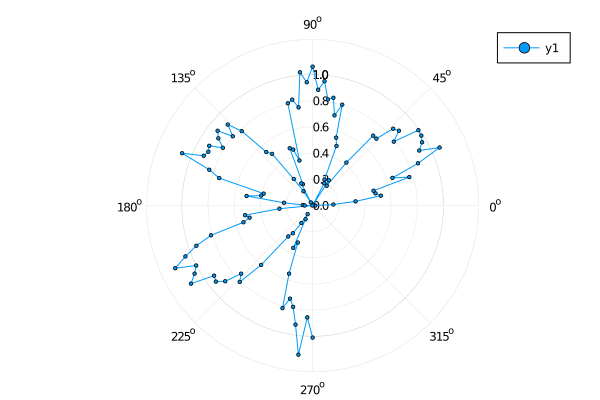

In [187]:
Θ = range(0, stop = 1.5π, length = 100)
r = abs.(0.1 * randn(100) + sin.(3Θ))
plot(Θ, r, proj = :polar, m = 2)

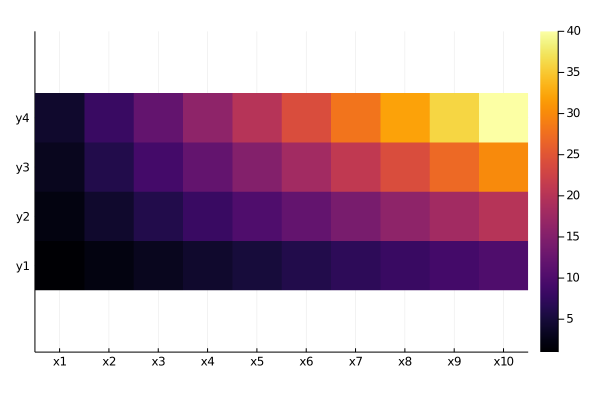

In [188]:
xs = [string("x", i) for i = 1:10]
ys = [string("y", i) for i = 1:4]
z = float((1:4) * reshape(1:10, 1, :))
Plots.heatmap(xs, ys, z, aspect_ratio = 1)

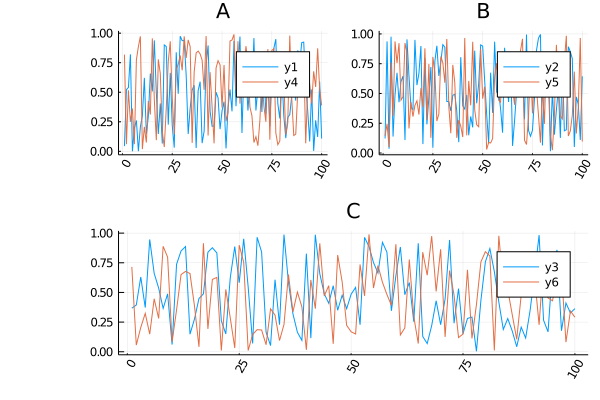

In [189]:
using Plots.PlotMeasures
plot(rand(100, 6), 
    layout = @layout([a b; c]), 
    title = ["A" "B" "C"], 
    #titlelocation = :left, 
    left_margin = [20mm 0mm], 
    bottom_margin = 10px, 
    xrotation = 60)

In [190]:
l = @layout([[a; b] c])
p = plot(plot([sin, cos], 1, leg = false), 
    scatter([atan, cos], 1, leg = false), 
    plot(log, 1, 
        xlims = (1, 10π), 
        ylims = (0, 5), leg = false), 
    layout = l)
anim = Animation()
for x = range(1, stop = 10π, length = 100)
    plot(push!(p, x, Float64[sin(x), cos(x), atan(x), cos(x), log(x)]))
    frame(anim)
end

UndefVarError: UndefVarError: scatter not defined

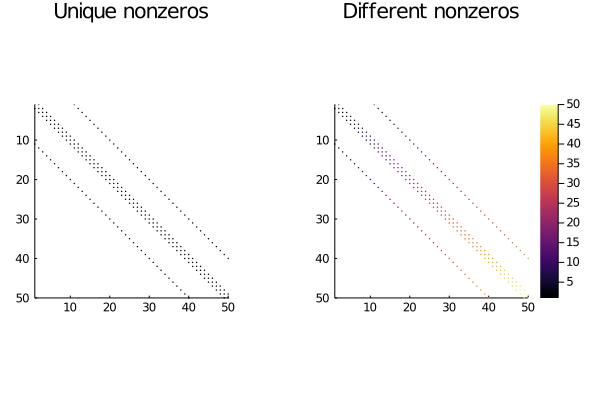

GKS: Possible loss of precision in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine CELLARRAY
invalid range


In [191]:
using SparseArrays
a = spdiagm(0 => ones(50), 1 => ones(49), -1 => ones(49), 10 => ones(40), -10 => ones(40))
b = spdiagm(0 => 1:50, 1 => 1:49, -1 => 1:49, 10 => 1:40, -10 => 1:40)
plot(spy(a), spy(b), title = ["Unique nonzeros" "Different nonzeros"])

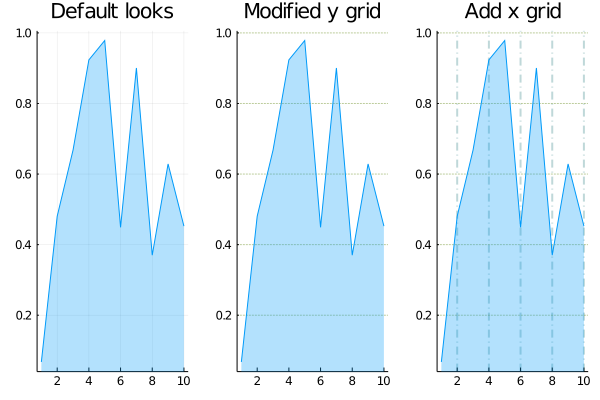

In [192]:
x = rand(10)
p1 = plot(x, title = "Default looks")
p2 = plot(x, grid = (:y, :olivedrab, :dot, 1, 0.9), title = "Modified y grid")
p3 = plot(deepcopy(p2), title = "Add x grid")
xgrid!(p3, :on, :cadetblue, 2, :dashdot, 0.4)
plot(p1, p2, p3, layout = (1, 3), label = "", fillrange = 0, fillalpha = 0.3)

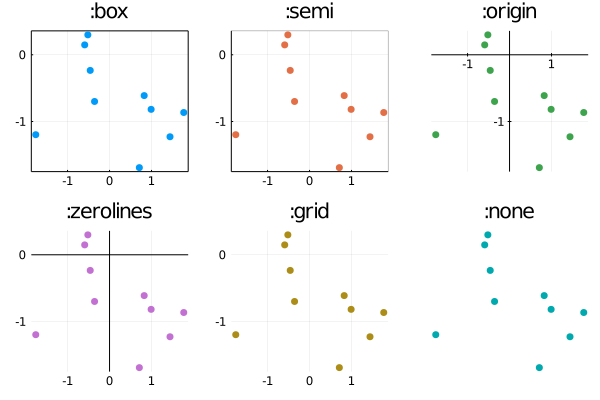

In [193]:
Plots.scatter(
    fill(randn(10), 6), 
    fill(randn(10), 6), 
    framestyle = [:box :semi :origin :zerolines :grid :none], 
    title = [":box" ":semi" ":origin" ":zerolines" ":grid" ":none"], 
    color = permutedims(1:6), 
    layout = 6, 
    label = "", 
    markerstrokewidth = 0, 
    ticks = -2:2)


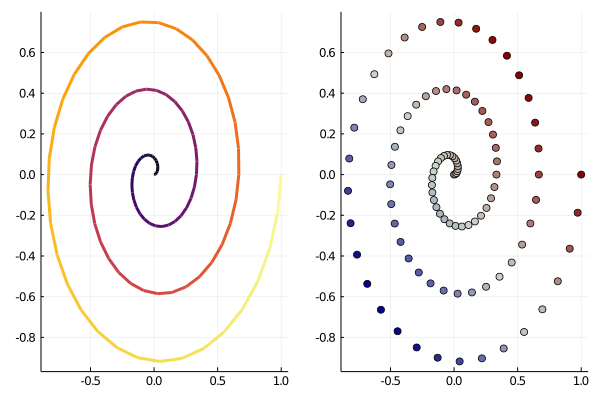

In [194]:
t = range(0, stop = 1, length = 100)
θ = (6π) .* t
x = t .* cos.(θ)
y = t .* sin.(θ)
p1 = plot(x, y, line_z = t, linewidth = 3, legend = false)
p2 = Plots.scatter(x, y, marker_z = (+), color = :bluesreds, legend = false)
plot(p1, p2)

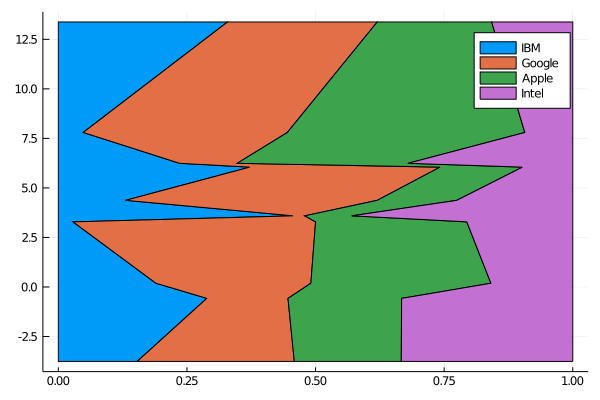

In [195]:
using Random
Random.seed!(111)
tickers = ["IBM", "Google", "Apple", "Intel"]
N = 10
D = length(tickers)
weights = rand(N, D)
weights ./= sum(weights, dims = 2)
returns = sort!((1:N) + D * randn(N))
portfoliocomposition(weights, returns, labels = permutedims(tickers))

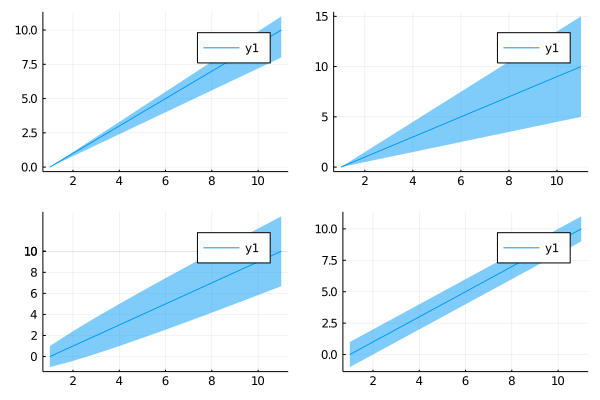

In [196]:
plot(
    plot(0:10; ribbon = (LinRange(0, 2, 11), LinRange(0, 1, 11))), 
    plot(0:10; ribbon = 0:0.5:5), 
    plot(0:10; ribbon = sqrt), 
    plot(0:10; ribbon = 1))


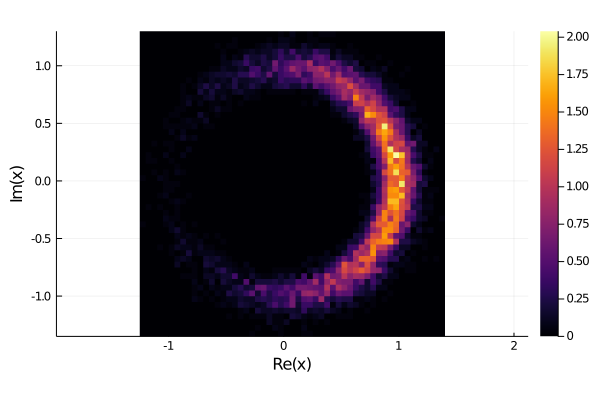

In [197]:
n = 10000 # 10000
x = exp.(0.1 * randn(n) .- randn(n) .* im)
histogram2d(x, 
    nbins = (100, 100), 
    show_empty_bins = true, 
    normed = true, 
    aspect_ratio = 1)

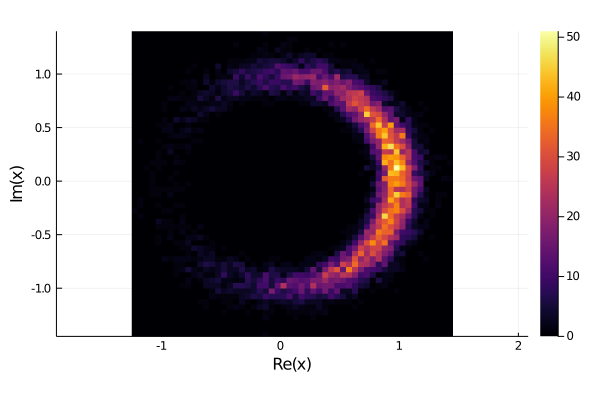

In [198]:
using Plots
gr() # https://github.com/jheinen/GR.jl

n = 10000 # 10000
x = exp.(0.1 * randn(n) .+ randn(n) .* im)

histogram2d(x, 
    nbins = (100, 100), 
    show_empty_bins = true, 
    normed = false, 
    aspect_ratio = .9)


In [199]:
savefig("Julia language eclipse.png")

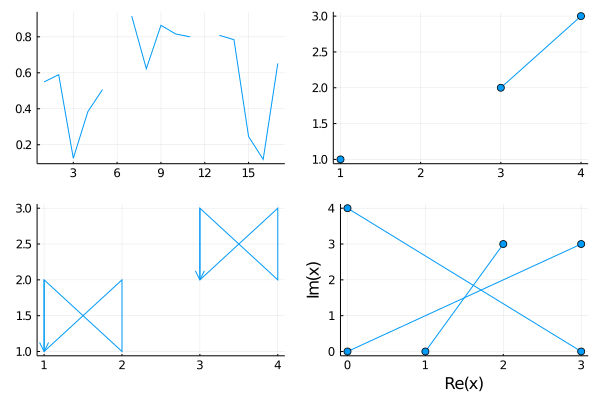

In [200]:
(x, y) = ([1, 2, 2, 1, 1], [1, 2, 1, 2, 1])
plot(
    plot([rand(5); NaN; rand(5); NaN; rand(5)]), 
    plot([1, missing, 2, 3], marker = true), 
    plot([x; NaN; x .+ 2], [y; NaN; y .+ 1], arrow = 2), 
    plot([1, 2 + 3im, Inf, 4im, 3, -Inf * im, 0, 3 + 3im], marker = true), 
    legend = false
)


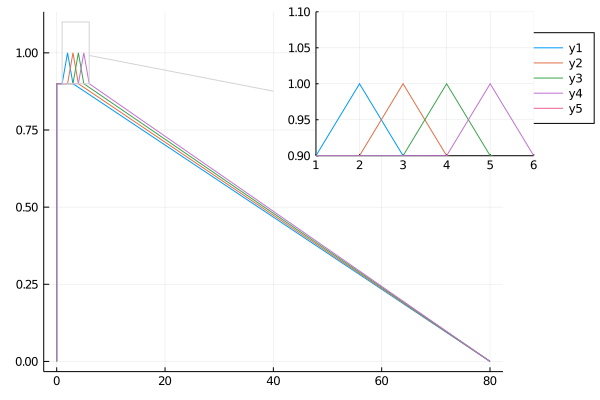

In [201]:
begin
    plot([(0, 0), (0, 0.9), (1, 0.9), (2, 1), (3, 0.9), (80, 0)], legend = :outertopright)
    plot!([(0, 0), (0, 0.9), (2, 0.9), (3, 1), (4, 0.9), (80, 0)])
    plot!([(0, 0), (0, 0.9), (3, 0.9), (4, 1), (5, 0.9), (80, 0)])
    plot!([(0, 0), (0, 0.9), (4, 0.9), (5, 1), (6, 0.9), (80, 0)])
    lens!([1, 6], [0.9, 1.1], inset = (1, bbox(0.5, 0.0, 0.4, 0.4)))
end

In [202]:


begin
    using StaticArrays, OffsetArrays
    sv = SVector{10}(rand(10))
    ov = OffsetVector(rand(10), -2)
    plot([sv, ov], label = ["StaticArray" "OffsetArray"])
    plot!(3ov, ribbon = ov, label = "OffsetArray ribbon")
end

BoundsError: BoundsError: attempt to access 10-element Base.OneTo{Int64} at index [11]

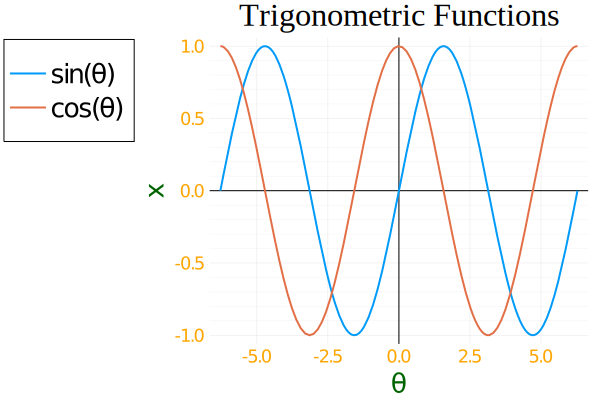

In [203]:
begin
    using Plots
    default(titlefont = (20, "times"), legendfontsize = 18, guidefont = (18, :darkgreen), tickfont = (12, :orange), guide = "x", framestyle = :zerolines, yminorgrid = true)
    plot([sin, cos], -2π, 2π, label = ["sin(θ)" "cos(θ)"], title = "Trigonometric Functions", xlabel = "θ", linewidth = 2, legend = :outertopleft)
end

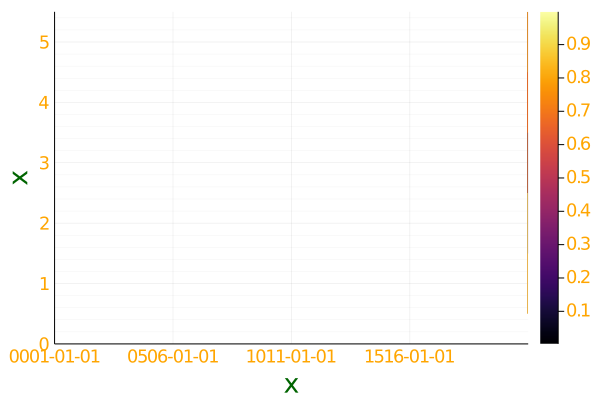

In [204]:
begin
    using Dates
    z = rand(5, 5)
    x = DateTime.(2016:2020)
    y = 1:5
    Plots.heatmap(x, y, z)
end

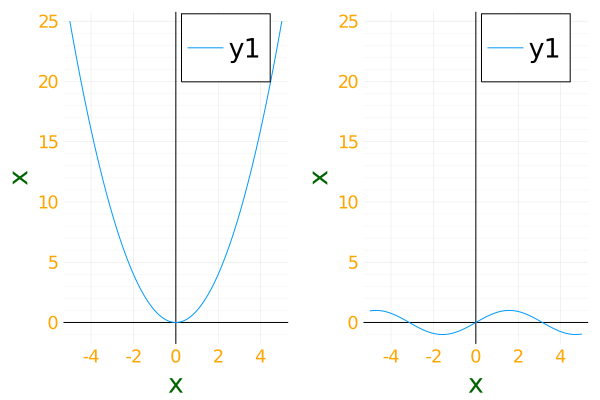

In [205]:
begin
    x = -5:0.1:5
    plot(plot(x, (x->begin
                    x ^ 2
                end)), plot(x, (x->begin
                    sin(x)
                end)), layout = 2, link = :y)
end

In [206]:
begin
    struct Measurement <: Number
        val::Float64
        err::Float64
    end
    value(m::Measurement) = begin
            m.val
        end
    uncertainty(m::Measurement) = begin
            m.err
        end
    @recipe function f(::Type{T}, m::T) where T <: AbstractArray{<:Measurement}
            if !(get(plotattributes, :seriestype, :path) in [:contour, :contourf, :contour3d, :heatmap, :surface, :wireframe, :image])
                error_sym = Symbol(plotattributes[:letter], :error)
                plotattributes[error_sym] = uncertainty.(m)
            end
            value.(m)
        end
    x = Measurement.(10 * sort(rand(10)), rand(10))
    y = Measurement.(10 * sort(rand(10)), rand(10))
    z = Measurement.(10 * sort(rand(10)), rand(10))
    surf = Measurement.((1:10) .* (1:10)', rand(10, 10))
    Plots.plot(scatter(x, [x y]), scatter(x, y, z), heatmap(x, y, surf), wireframe(x, y, surf), legend = :topleft)
end

UndefVarError: UndefVarError: scatter not defined

In [207]:

using GeometryBasics
using Distributions
d = MvNormal([1.0 0.75; 0.75 2.0])
plot([(1, 2), (3, 2), (2, 1), (2, 3)])
scatter!(Point2.(eachcol(rand(d, 1000))), alpha = 0.25)

ArgumentError: ArgumentError: Package Distributions not found in current path:
- Run `import Pkg; Pkg.add("Distributions")` to install the Distributions package.


In [208]:

using Plots
unicodeplots()

Plots.UnicodePlotsBackend()

In [209]:
plot(Plots.fakedata(50,5),w=3)


┌ Warning: Keyword argument fillcolor not supported with Plots.UnicodePlotsBackend().  Choose from: Set([:top_margin, :lims, :group, :background_color, :left_margin, :show_empty_bins, :seriesalpha, :zlink, :seriescolor, :smooth, :y, :margin, :zdiscrete_values, :bottom_margin, :zlims, :zerror, :html_output_format, :linestyle, :title, :subplot_index, :z, :bins, :zguide, :xguide, :markershape, :background_color_subplot, :xerror, :foreground_color_subplot, :ylims, :foreground_color, :primary, :x, :yerror, :legend, :discrete_values, :show, :link, :xdiscrete_values, :subplot, :label, :size, :projection, :guide, :ydiscrete_values, :yguide, :seriestype, :layout, :xlims, :right_margin, :xlink, :series_annotations, :ylink, :color_palette])
└ @ Plots /Users/uki/.julia/packages/Plots/8GUYs/src/args.jl:1140
┌ Warning: Keyword argument linecolor not supported with Plots.UnicodePlotsBackend().  Choose from: Set([:top_margin, :lims, :group, :background_color, :left_margin, :show_empty_bins, :seriesalp

                      +------------------------------------------------------------+   
    6.397007716894945 |,                                             ,             | y1
                      ||                                             ||.,          | y2
                      ||                                    .       .`]`l    .     | y3
                      ||                                   .^       . /.", / /, .` | y4
                      ||                                   /", /"\/l/.` .\/ " l |  | y5
                      ||           .   ,-              .  .` l_`,`"\..  |r\.  |=.` |   
                      ||          /.  .|\v._.     .    /, . ../,/   \/     "..1)|  |   
                      ||         ,`\ /@|.l.,l.  ./'\  ,`\ |.`` l/   '       \`| \  |   
                      ||       .r` "/.V./|/|||\ /   --` l |/   "  .          ||\/| |   
                      ||      .(.  .-]/\L \v|\/,`      ,|]/`     .^ . .      ||    |   
                      ||  r.  //

In [210]:
y = rand(100)
plot(0:10:100,rand(11,4),lab="lines",w=3,palette=:grays,fill=(0.5,:auto))
scatter!(y,z=abs(y - 0.5),m=(10,:heat),lab="grad")

┌ Warning: Keyword argument fillalpha not supported with Plots.UnicodePlotsBackend().  Choose from: Set([:top_margin, :lims, :group, :background_color, :left_margin, :show_empty_bins, :seriesalpha, :zlink, :seriescolor, :smooth, :y, :margin, :zdiscrete_values, :bottom_margin, :zlims, :zerror, :html_output_format, :linestyle, :title, :subplot_index, :z, :bins, :zguide, :xguide, :markershape, :background_color_subplot, :xerror, :foreground_color_subplot, :ylims, :foreground_color, :primary, :x, :yerror, :legend, :discrete_values, :show, :link, :xdiscrete_values, :subplot, :label, :size, :projection, :guide, :ydiscrete_values, :yguide, :seriestype, :layout, :xlims, :right_margin, :xlink, :series_annotations, :ylink, :color_palette])
└ @ Plots /Users/uki/.julia/packages/Plots/8GUYs/src/args.jl:1140


MethodError: MethodError: no method matching -(::Array{Float64,1}, ::Float64)
Closest candidates are:
  -(!Matched::Float64, ::Float64) at float.jl:403
  -(!Matched::Complex{Bool}, ::Real) at complex.jl:307
  -(!Matched::Missing, ::Number) at missing.jl:115
  ...

In [211]:
my_date = "Oct 11 2016" # needs updating

"Oct 11 2016"

In [212]:
using Dates

In [213]:
# Dates.DateTime(my_date, "d y u") # error Expected directive DatePart(d) at char 1
# Dates.DateTime(my_date, "m d y") # error: Expected directive DatePart(m) at char 1
# Dates.DateTime(my_date, 'u', 'd', 'y') # error : MethodError: no method matching Int64(::String)
Dates.DateTime(my_date, "u d y") # error  no method matching Int64(::String)

#Dates.DateTime(my_date, "u d y") # shows the desired format of the date time. 2015-11-25T00:00:00
# d - one or two digit day
# u - 3-letter abbreviation of the month
# y - 4-digit year

2016-10-11T00:00:00

In [214]:
using DelimitedFiles
indata = DelimitedFiles.readdlm("wikipediaEVDraw.csv", ',')  # 

54×9 Array{Any,2}:
 "25 Nov 2015"  28637  11314  3804  2536  …  4808     14122     3955
 "18 Nov 2015"  28634  11314  3804  2536     4808     14122     3955
 "11 Nov 2015"  28635  11314  3805  2536     4808     14122     3955
 "4 Nov 2015"   28607  11314  3810  2536     4808     14089     3955
 "25 Oct 2015"  28539  11298  3806  2535     4808     14061     3955
 "18 Oct 2015"  28476  11298  3803  2535  …  4808     14001     3955
 "11 Oct 2015"  28454  11297  3800  2534     4808     13982     3955
 "27 Sep 2015"  28388  11296  3805  2533     4808     13911     3955
 "20 Sep 2015"  28295  11295  3800  2532     4808     13823     3955
 "13 Sep 2015"  28220  11291  3792  2530     4808     13756     3953
 "6 Sep 2015"   28147  11291  3792  2530  …  4808     13683     3953
 "30 Aug 2015"  28073  11290  3792  2529     4808     13609     3953
 "16 Aug 2015"  27952  11284  3786  2524     4808     13494     3952
 ⋮                                        ⋱                     
 "9 Aug 2014"    18

In [215]:
subArray = indata[1:2,2:3]
subArray[1,1] = 1.0
subArray[1,2] = 2.0
subArray[2,1] = 3.0
subArray[2,2] = 4.0
subArray

2×2 Array{Any,2}:
 1.0  2.0
 3.0  4.0

In [216]:
println( sum(subArray[1:1,2:2]) )
#println( subArray(1,1) + subArray(2,2) ) # error MethodError: objects of type Array{Any,2} are not callable
println( subArray[1,1] + subArray[2,2] )

2.0
5.0


In [217]:
diagsum = 0
for k = 1:2
    diagsum = diagsum + subArray[k,k] # MethodError: no method matching +(::Int64, ::SubString{String})
end

println( diagsum)

5.0


In [218]:
litsamp = readdlm("litsampling.dat", ' ') # needs updating

2×6 Array{Any,2}:
 "The name of the rose"  "3.2,"  "7,"   8  9  100
 "Under Milk Wood"       "5.7,"  "11,"  3  6   42

In [219]:
day = indata[:,1]
liberia = indata[:,2]
guinea = indata[:,3]

plot(
    day, 
    [liberia,guinea ]
)

            +------------------------------------------------------------+   
   29495.24 | |----._______.                                             | y1
            | |            '"""""`---_.                                  | y2
            | |                       '`.                                |   
            | |                          "`.                             |   
            | |                            "`_                           |   
            | |                               \.                         |   
            | |                                ".                        |   
            | |                                 ".                       |   
            | |                                  ".                      |   
            | |                                   ",                     |   
            | |                                    \.                    |   
            | |___.                                 \           

In [220]:
using Plots
pyplot() # Use PyPlot as a GUI

x = collect(1:7) # makes a vector of integers out of the range 1:7

7-element Array{Int64,1}:
 1
 2
 3
 4
 5
 6
 7

In [221]:
f(x) = 2 - 2x + x^2/4

f (generic function with 2 methods)

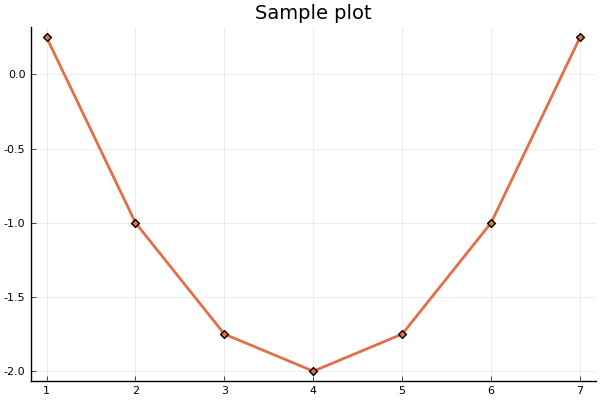

In [222]:

plot(x,f.(x))
plot!(x, f.(x), marker = :diamond, linewidth=2)
plot!(title = "Sample plot", leg=false)

In [223]:
x = [1 2 3 4 5 6]'

6×1 LinearAlgebra.Adjoint{Int64,Array{Int64,2}}:
 1
 2
 3
 4
 5
 6

In [224]:
x = [1 2 3 4 5 6]

1×6 Array{Int64,2}:
 1  2  3  4  5  6

In [225]:
x = [1, 2, 3, 4, 5, 6]

6-element Array{Int64,1}:
 1
 2
 3
 4
 5
 6

[1, 2, 3, 4, 5, 6]


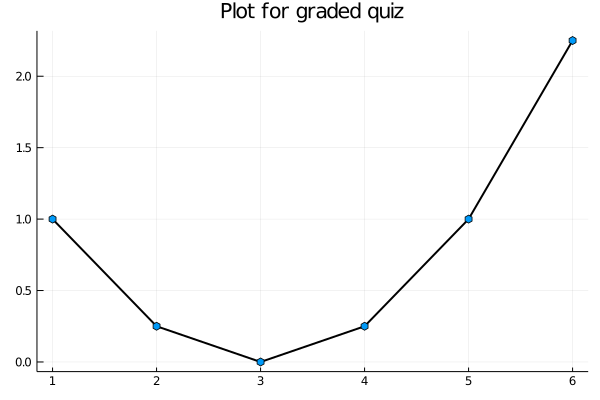

In [226]:
# Assume the Plots package is being used
using Plots
gr() # Activate the GR backend for use with Plots

x = [1, 2, 3, 4, 5, 6] # 1×6 Array{Int64,2}:
println(x)
y = (x.-3).^2/4
plot(x,y, marker = :hex, leg=false, linewidth = 2, linecolor=:black)
plot!(title="Plot for graded quiz")

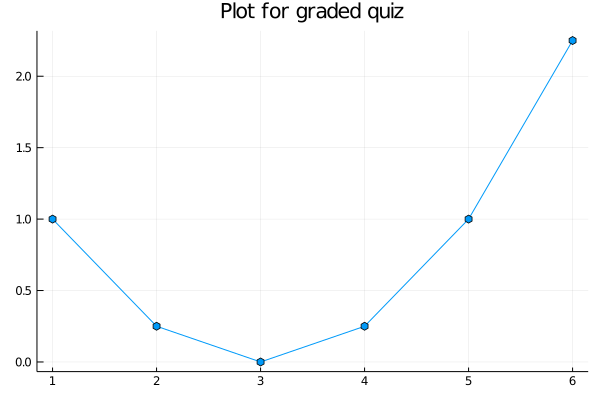

In [227]:
# Assume the Plots package is being used
using Plots
gr() # Activate the GR backend for use with Plots

x = [1 2 3 4 5 6]' # 6×1 LinearAlgebra.Adjoint{Int64,Array{Int64,2}}:
y = (x.-3).^2/4
plot(x,y, marker = :hex, leg=false)
plot!(title="Plot for graded quiz", linewidth = 2, linecolor=:black)

[1; 2; 3; 4; 5; 6]


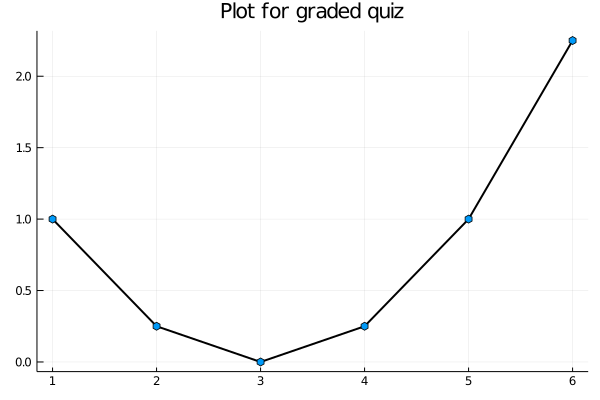

In [228]:
# Assume the Plots package is being used
using Plots
gr() # Activate the GR backend for use with Plots


x = [1 2 3 4 5 6]' # 6×1 LinearAlgebra.Adjoint{Int64,Array{Int64,2}}:
println(x)
y = (x.-3).^2/4
plot(x,y, marker = :hex, leg=false, linewidth = 2, linecolor=:black)
plot!(title="Plot for graded quiz")

[1 2 3 4 5 6]


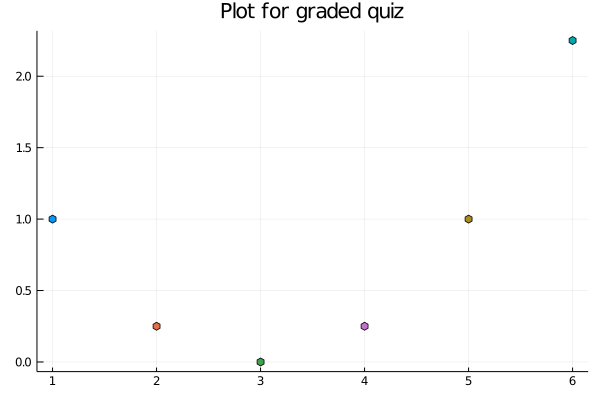

In [229]:
# Assume the Plots package is being used
using Plots
gr() # Activate the GR backend for use with Plots

x = [1 2 3 4 5 6] # 1×6 Array{Int64,2}:
println(x)
y = (x.-3).^2/4
plot(x,y, marker = :hex, leg=false, linewidth = 2, linecolor=:black)
plot!(title="Plot for graded quiz")

In [230]:
savefig("week 2 quiz plot 001.pdf") 

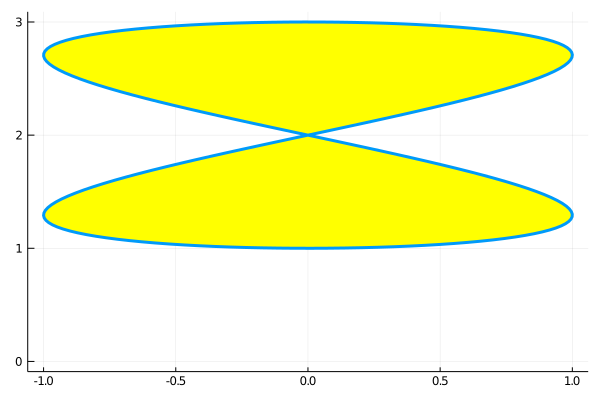

In [231]:
# just for fun

using Plots
gr() # Activate the GR backend for use with Plots https://github.com/jheinen/GR.jl
plot(sin, 
    (x->begin sin(0.5x) end +2), 
    0, 
    4π, 
    line = 3, 
    leg = false, 
    fill = (0, :yellow))